In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("../data/interim/cleaned_data.csv")
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


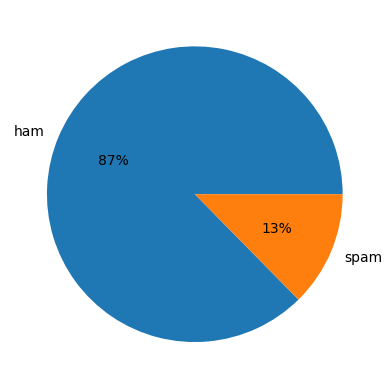

In [3]:
df["label"].value_counts().plot(kind="pie",autopct='%.0f%%')
plt.show()


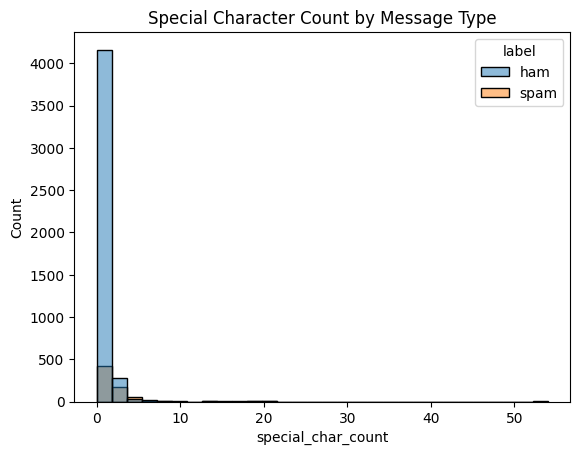

In [32]:
sns.histplot(
    data=df.assign(
        special_char_count=df["message"].str.count(r'[@#&$%+\-/*]')
    ),
    x="special_char_count",
    hue="label",
    bins=30
)

plt.title("Special Character Count by Message Type")
plt.show()

In [13]:
df.groupby("label")["message"].apply(lambda x: x.str.len().mean())

label
ham      70.905890
spam    137.704441
Name: message, dtype: float64

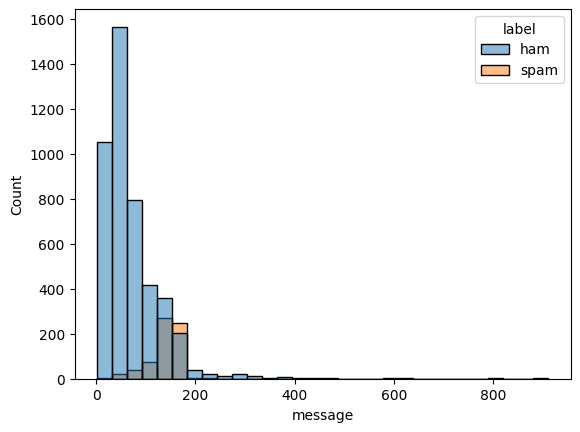

In [14]:
sns.histplot(
    data=df,
    x=df["message"].str.len(),
    hue="label",
    bins=30
)

plt.show()

In [5]:
df["message"].str.split().str.len().describe()

count    5169.000000
mean       15.439930
std        11.117073
min         1.000000
25%         7.000000
50%        12.000000
75%        22.000000
max       171.000000
Name: message, dtype: float64

AttributeError: module 'seaborn' has no attribute 'hist'

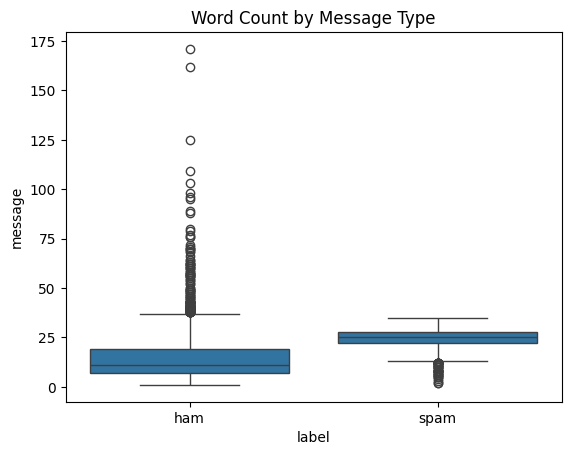

In [31]:
sns.boxplot(
    data=df,
    x="label",
    y=df["message"].str.split().str.len()
)

plt.title("Word Count by Message Type")
plt.show()